# Unemployment Analysis with Python

## Import Libraries

In [61]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [62]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

In [63]:
# Remove leading and trailing spaces from all column names
df.columns = df.columns.str.strip()

In [64]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [66]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


## Data Cleaning

In [67]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [68]:
df.drop_duplicates(inplace=True)

In [69]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
print(df.dtypes)

Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object


In [70]:
df['Region'].nunique()

28

In [71]:
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


## Exploratory Data Analysis (EDA)

In [72]:
df['Estimated Unemployment Rate (%)'].mean()

np.float64(11.787945945945946)

In [73]:
df.sort_values(
    'Estimated Unemployment Rate (%)',
    ascending=False
).head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
627,Puducherry,2020-04-30,Monthly,76.74,68122.0,35.54,Urban
628,Puducherry,2020-05-31,Monthly,75.00,64538.0,31.25,Urban
242,Puducherry,2020-04-30,Monthly,74.51,49420.0,46.79,Rural
531,Jharkhand,2020-05-31,Monthly,70.17,830347.0,40.49,Urban
530,Jharkhand,2020-04-30,Monthly,61.48,1054829.0,39.92,Urban


## Visualization 

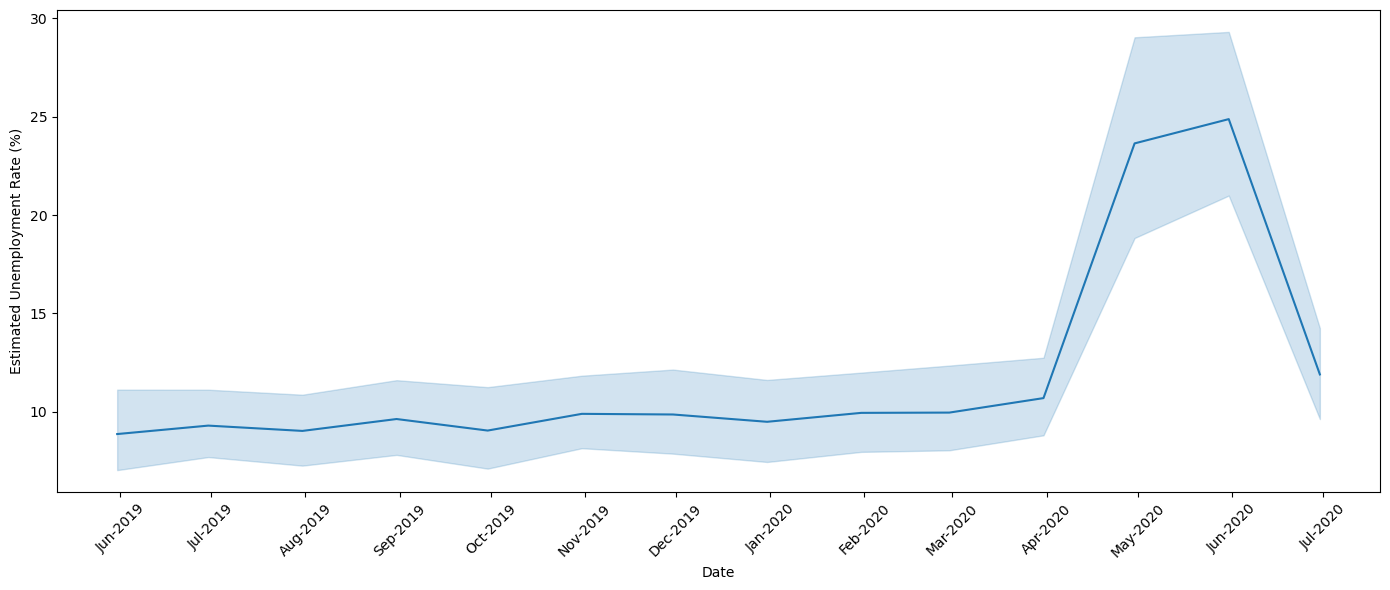

In [75]:
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

sns.lineplot(
    data=df,
    x='Date',
    y='Estimated Unemployment Rate (%)'
)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("unemployment_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The unemployment rate varies over time rather than remaining constant.
- A noticeable increase is observed during the COVID-19 period, reflecting the economic impact of lockdowns.
- After the peak, unemployment begins to stabilize in several regions, indicating gradual economic recovery.

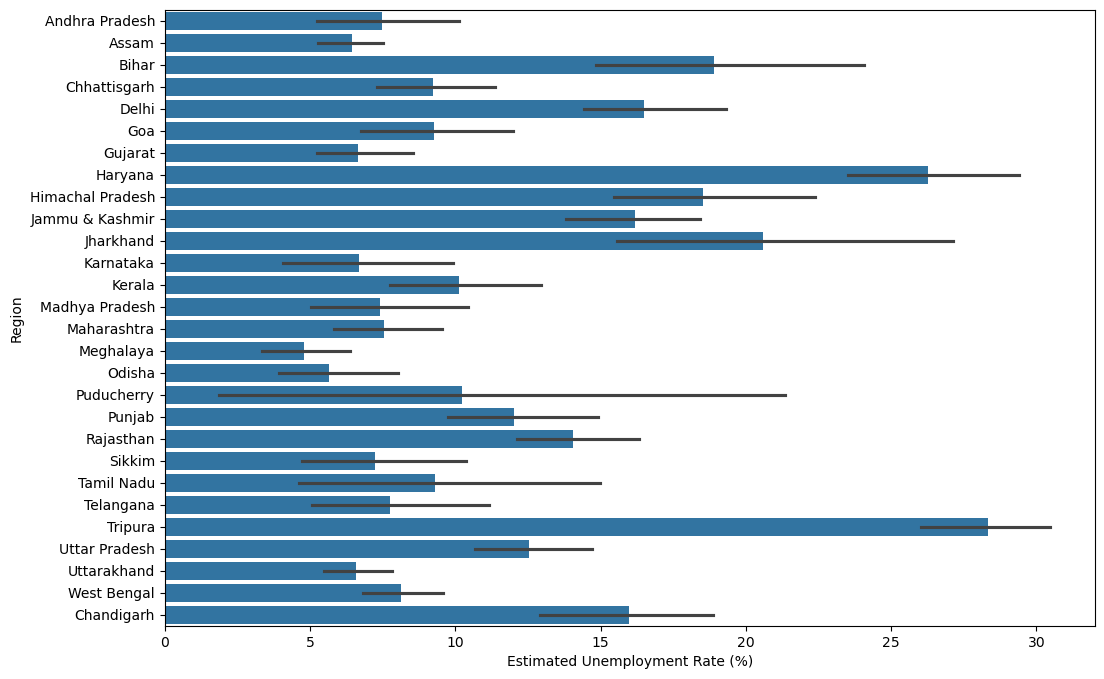

In [76]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=df,
    x='Estimated Unemployment Rate (%)',
    y='Region'
)
plt.savefig("statewise.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Unemployment rates differ significantly across regions.
- Some states consistently report higher unemployment than others.
- These regional differences suggest that economic conditions and employment opportunities vary across the country.

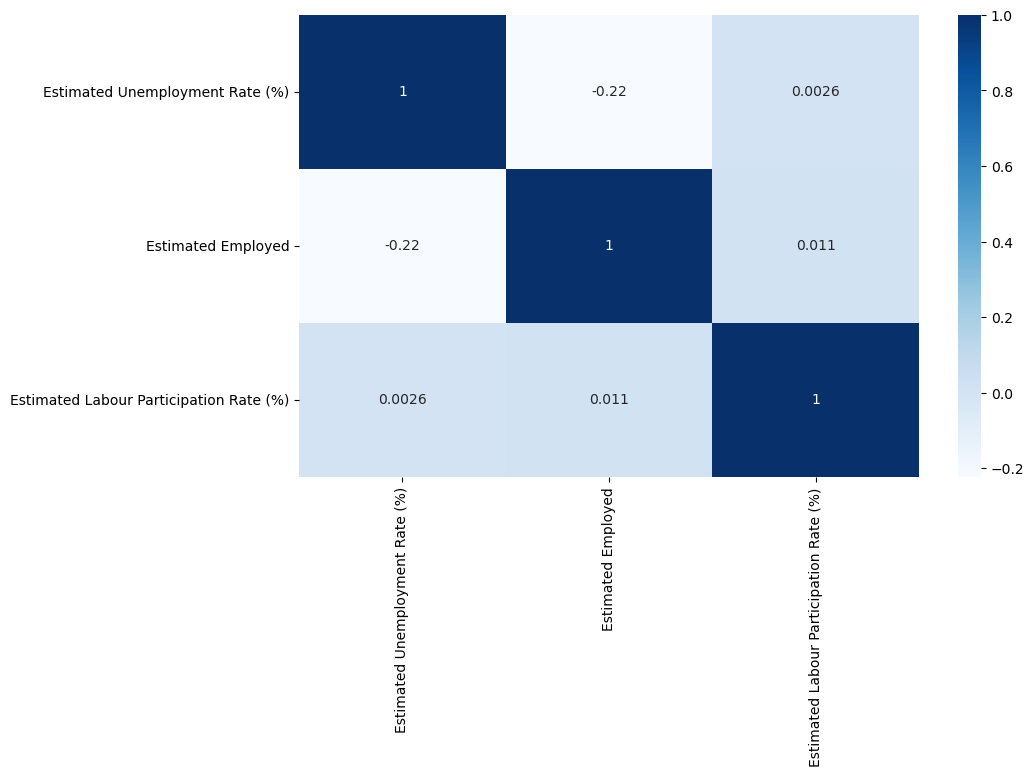

In [77]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)
plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The heatmap illustrates the relationships among numerical variables.
- A positive correlation indicates that two variables tend to increase together, while a negative correlation means one decreases as the other increases.
- Understanding these relationships helps identify factors associated with unemployment.

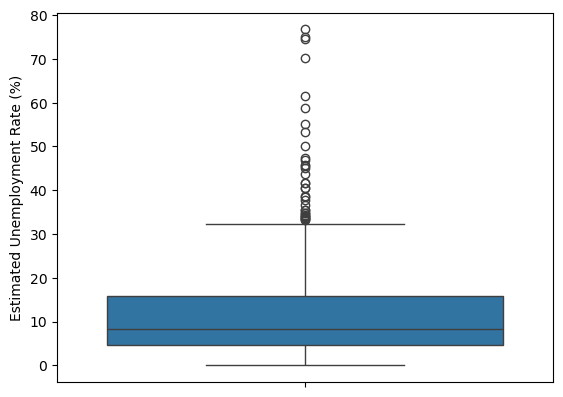

In [78]:
sns.boxplot(
    y=df['Estimated Unemployment Rate (%)']
)
plt.savefig("boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The box plot summarizes the spread of unemployment rates.
- Outliers indicate regions or time periods with exceptionally high unemployment.
- The median and interquartile range provide insight into the overall distribution of unemployment.

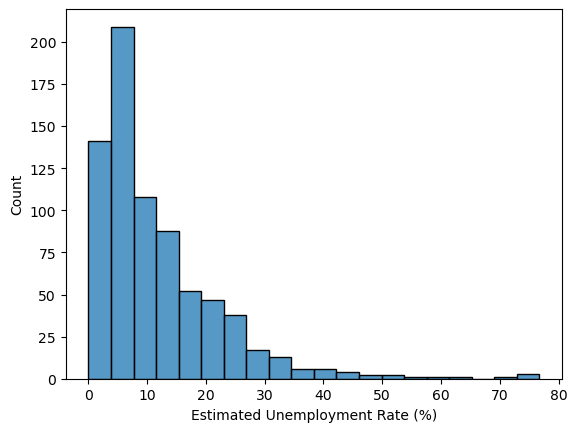

In [79]:
sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=20
)
plt.savefig("histogram.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Most unemployment rates are concentrated within a particular range.
- The distribution is not perfectly uniform, indicating that some unemployment levels occur more frequently than others.
- A few extreme values suggest that certain regions experienced unusually high unemployment.

## COVID-19 Impact Analysis

In [53]:
before_covid = df[df['Date'] < '2020-03-01']

In [54]:
during_covid = df[df['Date'] >= '2020-03-01']

In [55]:
before_avg = before_covid['Estimated Unemployment Rate (%)'].mean()

during_avg = during_covid['Estimated Unemployment Rate (%)'].mean()

print("Before COVID:", before_avg)

print("During COVID:", during_avg)

Before COVID: 9.509533582089553
During COVID: 17.774362745098042


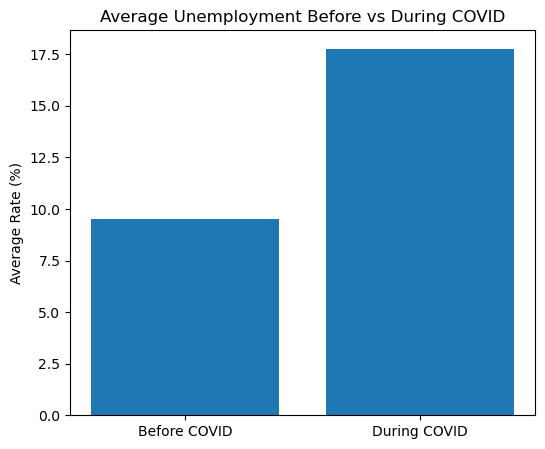

In [80]:
plt.figure(figsize=(6,5))

plt.bar(
    ['Before COVID', 'During COVID'],
    [before_avg, during_avg]
)

plt.title("Average Unemployment Before vs During COVID")

plt.ylabel("Average Rate (%)")
plt.savefig("covid_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The average unemployment rate increased during the COVID-19 period.
- This comparison highlights the significant economic impact of the pandemic on employment.
- The results suggest that lockdowns and reduced business activity contributed to higher unemployment.

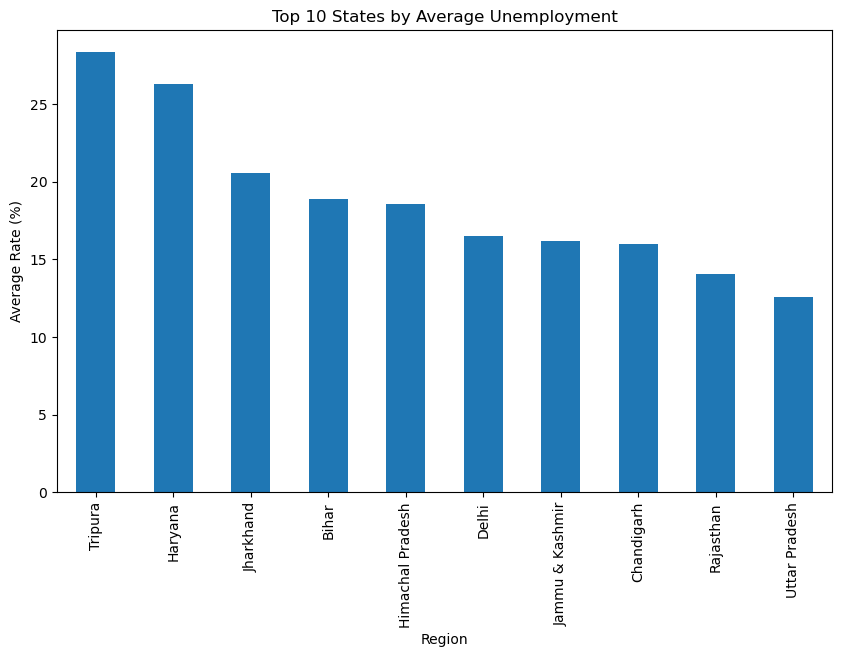

In [81]:
top10 = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

top10 = top10.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top10.plot(kind='bar')

plt.title("Top 10 States by Average Unemployment")

plt.ylabel("Average Rate (%)")
plt.savefig("top10_states.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The chart identifies the regions with the highest average unemployment rates.
- These states were more severely affected than others during the analysis period.
- Policymakers can prioritize employment support and economic recovery efforts in these regions.

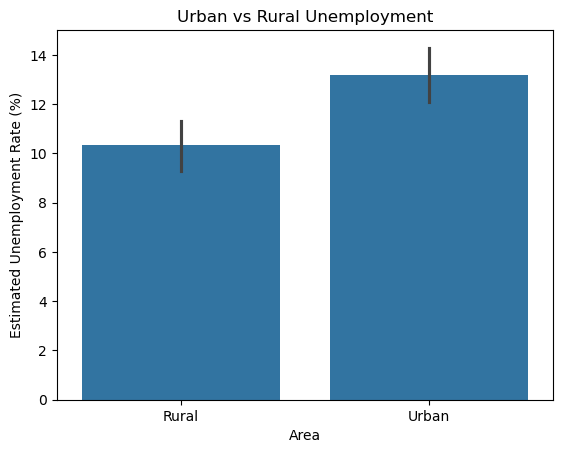

In [82]:
sns.barplot(
    data=df,
    x='Area',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Urban vs Rural Unemployment")
plt.savefig("urban_rural.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Unemployment rates differ between urban and rural areas.
- This indicates that the economic impact was not uniform across different types of regions.
- Such comparisons help in designing location-specific employment policies.

# Important Insights

- COVID-19 had a significant impact on unemployment, leading to a noticeable increase in unemployment rates.
- Unemployment levels varied considerably across different regions.
- Some states consistently recorded higher unemployment than others.
- The distribution of unemployment rates shows that a few regions experienced exceptionally high unemployment.
- Differences between urban and rural areas suggest that employment challenges were influenced by regional characteristics.
- These findings can support policymakers in developing targeted employment and economic recovery strategies.

# Conclusion

This project analyzed unemployment trends using Python by performing data cleaning, exploratory data analysis, and visualization. The analysis shows that unemployment rates increased during the COVID-19 pandemic and varied across different regions. Visualizations highlighted regional differences, the distribution of unemployment, and the impact on urban and rural areas. These insights can help governments and policymakers design targeted employment initiatives and support economic recovery.